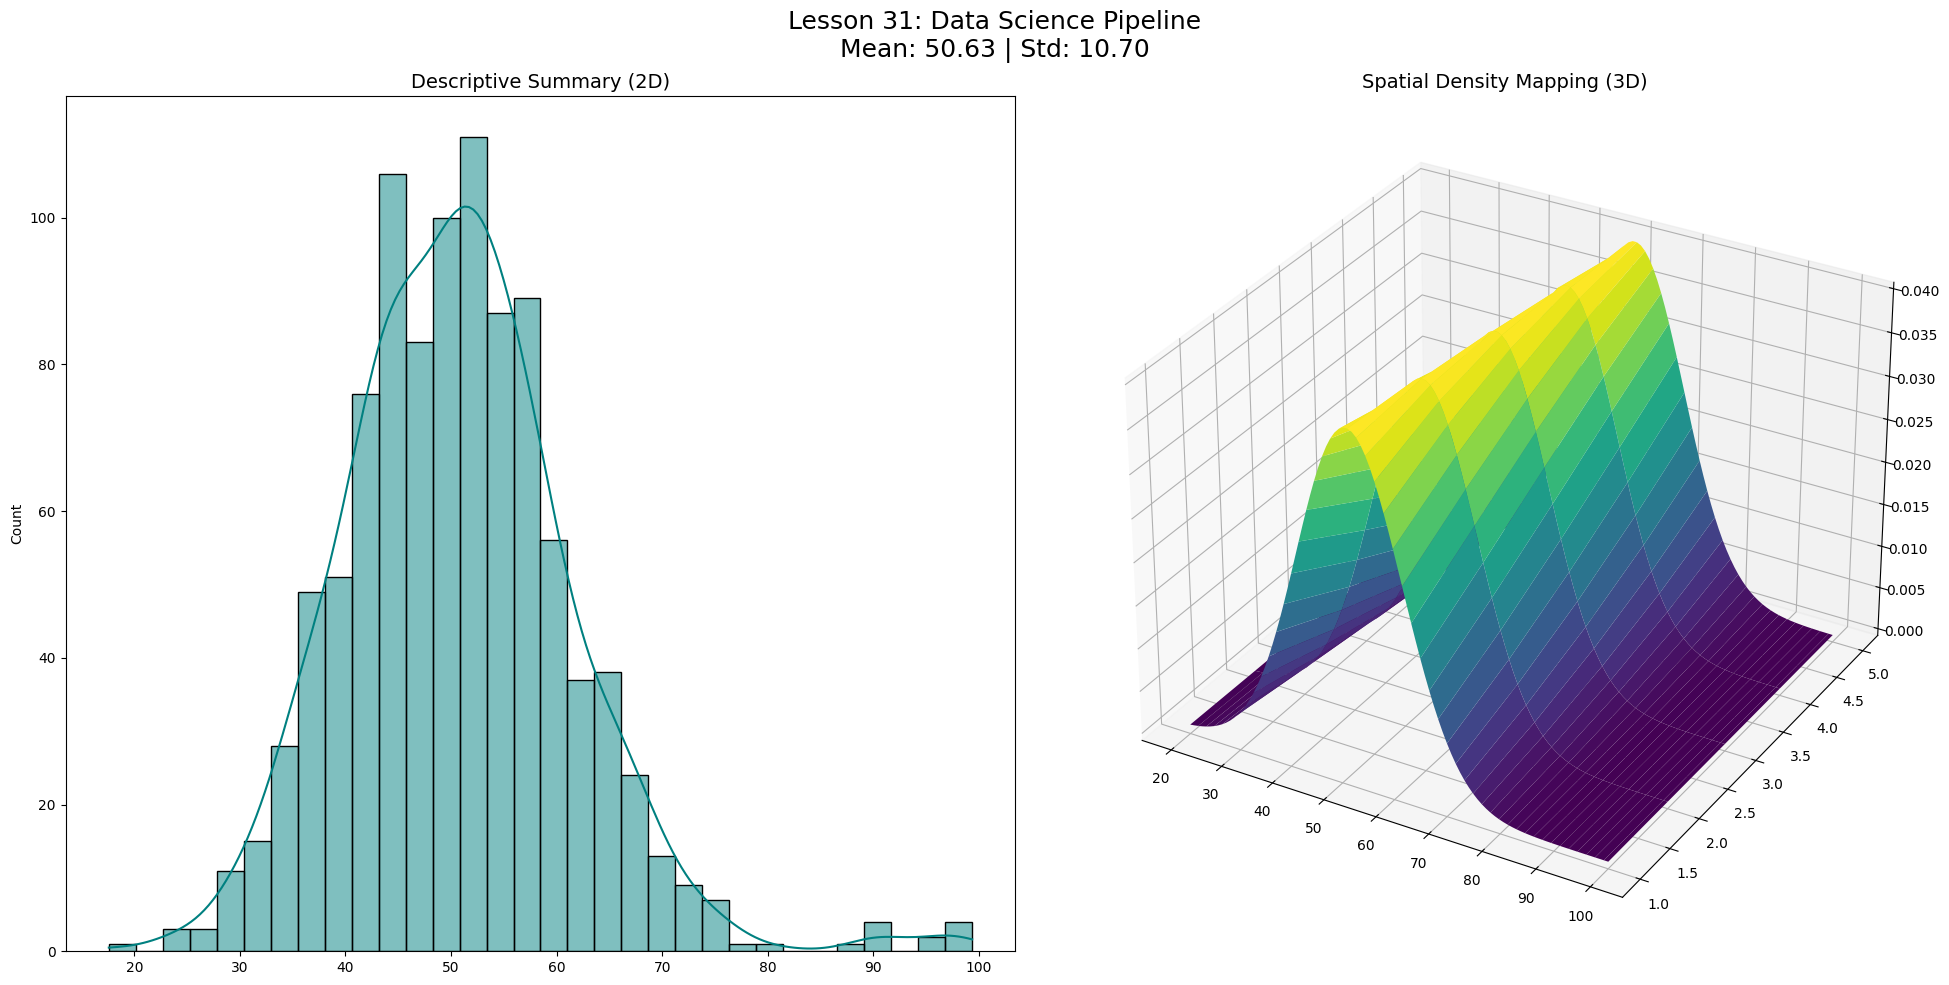

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats
import os

def run_stats_pipeline():
    # Assets yolu
    asset_path = '../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # 1. Veri Üretimi (Normal Dağılım + Biraz Gürültü ve Aykırı Değer)
    np.random.seed(42)
    data = np.random.normal(loc=50, scale=10, size=1000)
    outliers = np.random.uniform(low=90, high=100, size=10)
    data = np.concatenate([data, outliers])

    # --- ASSET 1: 2D VISUALIZATION (Histogram + BoxPlot) ---
    fig2d, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 8))
    
    sns.boxplot(x=data, ax=ax_box, color='skyblue')
    sns.histplot(x=data, ax=ax_hist, kde=True, color='navy')
    
    ax_box.set(title='2D Descriptive Analysis: Distribution & Outliers')
    ax_hist.set(xlabel='Value Range', ylabel='Frequency')
    
    plt.savefig(f'{asset_path}/31_stats_2d.png', dpi=300)
    plt.close(fig2d) # Dashboard için ayrı saklıyoruz

    # --- ASSET 2: 3D VISUALIZATION (Density Surface) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    # Veriyi gruplara ayırıp yoğunluk yüzeyi oluşturma (Örn: 5 farklı zaman dilimi gibi)
    x_range = np.linspace(20, 100, 100)
    y_steps = np.arange(1, 6)
    X, Y = np.meshgrid(x_range, y_steps)
    Z = np.array([stats.norm.pdf(x_range, loc=50+(i*2), scale=10) for i in y_steps])

    surf = ax3d.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
    ax3d.set_title("3D Distribution Evolution Surface")
    ax3d.set_xlabel('Value'); ax3d.set_ylabel('Sample Group'); ax3d.set_zlabel('Density')
    
    plt.savefig(f'{asset_path}/31_stats_3d.png', dpi=300)
    plt.close(fig3d)

    # --- MASTER DASHBOARD (2D ve 3D Beraber) ---
    master_fig = plt.figure(figsize=(20, 10))
    
    # Left: 2D Histogram/Box
    ax1 = master_fig.add_subplot(121)
    sns.histplot(data, kde=True, ax=ax1, color='teal')
    ax1.set_title("Descriptive Summary (2D)", fontsize=14)

    # Right: 3D Surface
    ax2 = master_fig.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='viridis')
    ax2.set_title("Spatial Density Mapping (3D)", fontsize=14)

    plt.suptitle(f"Lesson 31: Data Science Pipeline\nMean: {np.mean(data):.2f} | Std: {np.std(data):.2f}", fontsize=18)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_stats_pipeline()